Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 26, 26, 64)        640       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 13, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 11, 11, 32)        18464     
                                                                 
 average_pooling2d_1 (Avera  (None, 5, 5, 32)          0         
 gePooling2D)                                                    
                                                                 
 conv2d_8 (Conv2D)           (None, 3, 3, 16)          4624      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 1, 1, 16)         

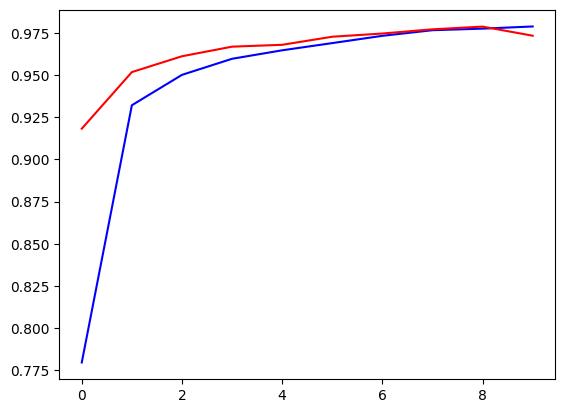

In [21]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test)= mnist.load_data()
x_train.shape

# idx = 0
# plt.imshow(x_train[idx],cmap='gray')
# plt.show()

# Normalization (0 and 1)
x_train = x_train.reshape((-1,28,28,1)).astype('float32') / 255
x_test = x_test.reshape((-1,28,28,1)).astype('float32') / 255
x_test.shape

# model = keras.Sequential()
# # Each of the 32 filters extracts a different feature from the image, resulting in 32 different output images (feature maps)
# model.add(keras.layers.Conv2D(32, kernel_size=(3,3),strides=(1,1), padding='valid', activation='relu',input_shape=(28,28,1)))
# model.add(keras.layers.Flatten())
# model.add(keras.layers.Dense(units=128, activation='relu'))
# model.add(keras.layers.Dense(units=10, activation ='softmax'))

model = keras.Sequential()
model.add(keras.layers.Conv2D(64, kernel_size=(3,3),strides=(1,1), padding='valid', activation='relu',input_shape=(28,28,1)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Conv2D(32, kernel_size=(3,3),strides=(1,1), padding='valid', activation='relu'))
model.add(keras.layers.AveragePooling2D(pool_size=(2,2)))
model.add(keras.layers.Conv2D(16, kernel_size=(3,3),strides=(1,1), padding='valid', activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(units=256, activation='relu'))
model.add(keras.layers.Dense(units=10, activation ='softmax'))

model.compile(optimizer=tf.optimizers.Adam(), loss=tf.losses.sparse_categorical_crossentropy, metrics= ['accuracy'])

model.summary()

hist = model.fit(x_train, y_train, epochs=10, batch_size=256, validation_data=(x_test,y_test))

plt.plot(hist.history['accuracy'],color='blue')
plt.plot(hist.history['val_accuracy'],color='red')
